In [ ]:
from graphviz import Digraph
from IPython.display import display

# Inisialisasi diagram
dot = Digraph(comment='Pipeline Pemrosesan Bahasa', format='png')
dot.attr(rankdir='TB')  # Alur dari atas ke bawah

# Styling default untuk semua node proses (Kotak / Box)
dot.attr('node', shape='box', style='rounded,filled', fillcolor='#E3F2FD',
         color='#1976D2', fontname='Helvetica', fontsize='11', height='0.6')
dot.attr('edge', color='#455A64', arrowhead='vee', arrowsize='0.8')

# Node Start & End (Hanya ini yang berbentuk Oval)
dot.node('start', 'Start', shape='oval', fillcolor='#C8E6C9', color='#388E3C')
dot.node('end', 'End', shape='oval', fillcolor='#FFCDD2', color='#D32F2F')

# Node Proses (Otomatis berbentuk kotak rounded dari styling default)
dot.node('input', 'User Input\n(Audio/Text)')
dot.node('sintaksis', 'Memproses Sintaksis')
dot.node('morfologi', 'Mengolah/Memproses Morfologi')
dot.node('semantik', 'Mengolah/Memproses Semantik')
dot.node('pragmatis', 'Mengolah/Memproses Pragmatis')
dot.node('kalimat', 'Memproses Kalimat\nyang Sudah Jadi')
dot.node('output', 'Menjalankan Fungsinya')

# Hubungan alur (Edges)
dot.edge('start', 'input')
dot.edge('input', 'sintaksis')
dot.edge('sintaksis', 'morfologi')
dot.edge('morfologi', 'semantik')
dot.edge('semantik', 'pragmatis')
dot.edge('pragmatis', 'kalimat')
dot.edge('kalimat', 'output')
dot.edge('output', 'end')

# Menampilkan langsung di output Colab
display(dot)

#Framework Hybrid BiLSTM-Genetic Algorithm Untuk Prediksi Delay Penerbangan Dan Optimalisasi Penugasan Gate Bandara Secara Adaptif

##Members
### Ilham Rizky Handriansyah
### Haryo Seto Wicaksono
### Bagas Pamungkas

# 1A: CONFIGURATION & INITIALIZATION

In [ ]:
import os
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

@dataclass
class CFG:
    CSV_PATH: str = "/content/flights.csv"
    WINDOW: int = 5
    MIN_TAIL_LEN: int = 8
    TARGET_CLIP: float = 180.0
    VAL_DAYS: int = 30
    DROPOUT: float = 0.25
    LSTM_UNITS_1: int = 128
    LSTM_UNITS_2: int = 64
    DENSE_UNITS: int = 64
    LR: float = 5e-4
    EPOCHS: int = 20
    BATCH_SIZE: int = 1024
    SEED: int = 42

    # Memory control & balanced sampling per bulan
    CHUNK_SIZE: int = 250_000
    MAX_ROWS_TOTAL: int = 1_200_000
    MONTHS: Tuple[int, ...] = (1,2,3,4,5,6,7,8,9,10,11,12)
    MAX_WINDOWS_PER_TAIL: int = 300
    MAX_TOTAL_WINDOWS: int = 1_200_000

@dataclass
class COLS:
    FlightDate: str = "FLIGHT_DATE_PARSED"
    Tail: str = "TAIL_NUMBER"
    ArrDelay: str = "ARRIVAL_DELAY"
    DepDelay: str = "DEPARTURE_DELAY"
    Airline: str = "AIRLINE"
    DepAirport: str = "ORIGIN_AIRPORT"
    ArrAirport: str = "DESTINATION_AIRPORT"
    DayOfWeek: str = "DAY_OF_WEEK"
    FlightDuration: str = "SCHEDULED_TIME"
    DistanceType: str = "DISTANCE"
    ScheduledArr: str = "SCHEDULED_ARRIVAL"
    WeatherDelay: str = "WEATHER_DELAY"
    AirSystemDelay: str = "AIR_SYSTEM_DELAY"
    AirlineDelay: str = "AIRLINE_DELAY"
    LateAircraftDelay: str = "LATE_AIRCRAFT_DELAY"
    SecurityDelay: str = "SECURITY_DELAY"

cfg = CFG()
cols = COLS()

def set_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seeds(cfg.SEED)
print("[Sistem-BiLSTM] Konfigurasi dan seeding selesai disiapkan.")

[Sistem-BiLSTM] Konfigurasi dan seeding selesai disiapkan.


## 1B: BALANCED DATA LOADER & TARGET TRANSFORM FUNCTIONS

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
from google.colab import drive

def signed_log1p(x: np.ndarray) -> np.ndarray:
    return np.sign(x) * np.log1p(np.abs(x))

def signed_expm1(x: np.ndarray) -> np.ndarray:
    return np.sign(x) * (np.expm1(np.abs(x)))

def inverse_transform(y_t: np.ndarray) -> np.ndarray:
    return signed_expm1(np.asarray(y_t).reshape(-1)).astype(np.float32)

def load_and_preprocess_balanced(csv_path: str) -> pd.DataFrame:
    usecols = [
        "YEAR","MONTH","DAY", cols.Tail, cols.Airline, cols.DepAirport, cols.ArrAirport, cols.DayOfWeek,
        cols.DepDelay, cols.ArrDelay, cols.FlightDuration, cols.DistanceType, cols.ScheduledArr,
        cols.WeatherDelay, cols.AirSystemDelay, cols.AirlineDelay, cols.LateAircraftDelay, cols.SecurityDelay,
        "FLIGHT_NUMBER", "CANCELLED", "DIVERTED"
    ]
    dtype_map = {
        "YEAR": "int16", "MONTH": "int8", "DAY": "int8", cols.DayOfWeek: "int8",
        "FLIGHT_NUMBER": "int32", "CANCELLED": "int8", "DIVERTED": "int8",
        cols.ScheduledArr: "int16", cols.FlightDuration: "float32", cols.DistanceType: "float32",
        cols.DepDelay: "float32", cols.ArrDelay: "float32", cols.WeatherDelay: "float32",
        cols.AirSystemDelay: "float32", cols.AirlineDelay: "float32", cols.LateAircraftDelay: "float32",
        cols.SecurityDelay: "float32", cols.Tail: "string", cols.Airline: "string",
        cols.DepAirport: "string", cols.ArrAirport: "string"
    }

    rng = np.random.RandomState(cfg.SEED)

    target_per_month = max(1, cfg.MAX_ROWS_TOTAL // len(cfg.MONTHS))

    collected = {m: 0 for m in cfg.MONTHS}
    parts = []

    print(f"[BiLSTM] Membaca CSV dan menyeimbangkan sample (~{target_per_month:,} baris/bulan)...")
    for chunk in pd.read_csv(csv_path, usecols=usecols, dtype=dtype_map, low_memory=False, chunksize=cfg.CHUNK_SIZE):
        chunk = chunk[chunk["MONTH"].isin(set(cfg.MONTHS))]
        if len(chunk) == 0:
            continue

        if "CANCELLED" in chunk.columns:
            chunk = chunk[chunk["CANCELLED"].fillna(0).astype(int) == 0]
        if "DIVERTED" in chunk.columns:
            chunk = chunk[chunk["DIVERTED"].fillna(0).astype(int) == 0]
        chunk = chunk.dropna(subset=[cols.Tail, cols.ArrDelay, cols.DepDelay, cols.ScheduledArr])

        sampled_rows = []
        for m in cfg.MONTHS:
            need = target_per_month - collected[m]
            if need <= 0: continue
            sub = chunk[chunk["MONTH"] == m]
            if len(sub) == 0: continue
            take = min(need, len(sub))
            sampled_rows.append(sub.sample(n=take, random_state=rng))
            collected[m] += take
        if sampled_rows: parts.append(pd.concat(sampled_rows, ignore_index=True))
        if all(collected[m] >= target_per_month for m in cfg.MONTHS): break

    df = pd.concat(parts, ignore_index=True)
    df[cols.FlightDate] = pd.to_datetime(df["YEAR"].astype(str) + "-" + df["MONTH"].astype(str) + "-" + df["DAY"].astype(str), errors="coerce")
    df = df.dropna(subset=[cols.FlightDate]).reset_index(drop=True)

    numeric_cols = [cols.ArrDelay, cols.DepDelay, cols.FlightDuration, cols.DistanceType, cols.WeatherDelay, cols.AirSystemDelay, cols.AirlineDelay, cols.LateAircraftDelay, cols.SecurityDelay]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0).astype(np.float32)

    df["DELTA_DELAY"] = (df[cols.ArrDelay] - df[cols.DepDelay]).clip(-cfg.TARGET_CLIP, cfg.TARGET_CLIP).astype(np.float32)
    return df.sort_values([cols.Tail, cols.FlightDate]).reset_index(drop=True)


def pastikan_dan_muat_data_seimbang(cfg_obj):
    lokal_path = "/content/flights.csv"
    drive_source_path = "/content/drive/MyDrive/flights.csv"

    print("\n" + "="*90)
    print(" [Sistem-Hybrid] MEMERIKSA KETERSEDIAAN DATASET FLIGHTS.CSV")
    print("="*90)

    # Cek apakah file sudah ada di lokal temporary Colab
    if os.path.exists(lokal_path):
        print(f"[✓] Dataset sudah aman di lokal Colab: '{lokal_path}'")
    else:
        print("[!] Dataset TIDAK ada di lokal Colab.")
        print("[] Mencoba menghubungkan Google Drive dan menyalin data...")

        if not os.path.exists("/content/drive"):
            drive.mount('/content/drive')

        if os.path.exists(drive_source_path):
            print(f"[] Menyalin file: '{drive_source_path}' ➡️ '{lokal_path}'...")
            shutil.copy(drive_source_path, lokal_path)
            print("[✓] Sinkronisasi sukses! File berhasil disimpan di lokal Colab.")
        else:
            print(f"\n[❌] ERROR: File tidak ada di Drive pada jalur: '{drive_source_path}'")
            print("Pastikan file 'flights.csv' ditaruh di folder utama (My Drive) Anda.")
            raise FileNotFoundError(f"File tidak ada di lokal maupun Drive.")

    print("-" * 90)
    return load_and_preprocess_balanced(lokal_path)

df_raw = pastikan_dan_muat_data_seimbang(cfg)

print("\n[Sistem-BiLSTM] CELL 1B Berhasil Diperbarui & Bebas Error.")


 [Sistem-Hybrid] MEMERIKSA KETERSEDIAAN DATASET FLIGHTS.CSV
[✓] Dataset sudah aman di lokal Colab: '/content/flights.csv'
------------------------------------------------------------------------------------------
[BiLSTM] Membaca CSV dan menyeimbangkan sample (~100,000 baris/bulan)...

[Sistem-BiLSTM] CELL 1B Berhasil Diperbarui & Bebas Error.


# 1C: VOCABULARY & CAP-WINDOW SEQUENCE BUILDER FUNCTIONS

In [ ]:
@dataclass
class Vocabs:
    airline: Dict[str, int]; dep_airport: Dict[str, int]; arr_airport: Dict[str, int]; tail: Dict[str, int]; day_of_week: Dict[str, int]

def get_vocab(series: pd.Series) -> Dict[str, int]:
    return {k: i + 1 for i, k in enumerate(series.fillna("UNK").astype(str).unique())}

def apply_vocab(series: pd.Series, vocab: Dict[str, int]) -> np.ndarray:
    return series.fillna("UNK").astype(str).map(lambda x: vocab.get(x, 0)).astype(np.int32).to_numpy()

def make_sequences_raw_capped(df: pd.DataFrame, vocabs: Vocabs) -> Tuple[Dict[str, np.ndarray], np.ndarray, List[int]]:
    num_cols = [cols.DepDelay, cols.FlightDuration, cols.DistanceType, cols.WeatherDelay, cols.AirSystemDelay, cols.AirlineDelay, cols.LateAircraftDelay, cols.SecurityDelay]
    cat_map = {"airline": cols.Airline, "dep_airport": cols.DepAirport, "arr_airport": cols.ArrAirport, "day_of_week": cols.DayOfWeek}
    row_cat_ids = {key: apply_vocab(df[colname], getattr(vocabs, key)) for key, colname in cat_map.items()}

    X_num_list, X_tail_list, y_list, meta_indices = [], [], [], []
    X_cat_seq = {k: [] for k in row_cat_ids.keys()}
    rng = np.random.RandomState(cfg.SEED)
    total_windows = 0

    for tail_value, group in df.groupby(cols.Tail, sort=False):
        if len(group) < max(cfg.WINDOW + 1, cfg.MIN_TAIL_LEN): continue
        idx = group.index.to_numpy()
        num_mat = df.loc[idx, num_cols].to_numpy(dtype=np.float32)
        tail_id = int(vocabs.tail.get(str(tail_value), 0))
        t_positions = np.arange(cfg.WINDOW, len(idx))

        if len(t_positions) > cfg.MAX_WINDOWS_PER_TAIL:
            t_positions = rng.choice(t_positions, size=cfg.MAX_WINDOWS_PER_TAIL, replace=False)
            t_positions.sort()

        for t in t_positions:
            if total_windows >= cfg.MAX_TOTAL_WINDOWS: break
            X_num_list.append(num_mat[t - cfg.WINDOW:t, :])
            for k in row_cat_ids.keys(): X_cat_seq[k].append(row_cat_ids[k][idx[t - cfg.WINDOW:t]])
            X_tail_list.append(tail_id)
            y_list.append(df.loc[idx[t], "DELTA_DELAY"])
            meta_indices.append(int(idx[t]))
            total_windows += 1
        if total_windows >= cfg.MAX_TOTAL_WINDOWS: break

    if len(X_num_list) == 0:
        raise ValueError("[Kritis] X_num_list kosong! Data yang lolos sekuens tidak ada. Periksa kembali ukuran sampling dataset Anda.")

    X = {"x_num": np.stack(X_num_list).astype(np.float32), "x_tail": np.array(X_tail_list, dtype=np.int32)}
    for k, v in X_cat_seq.items(): X[f"x_{k}"] = np.stack(v).astype(np.int32)
    return X, np.array(y_list, dtype=np.float32).reshape(-1, 1), meta_indices

def scale_x_num(X: Dict[str, np.ndarray], scaler: StandardScaler, fit: bool) -> Tuple[Dict[str, np.ndarray], StandardScaler]:
    X2 = dict(X)
    F = X2["x_num"].shape[-1]
    if fit: X2["x_num"] = scaler.fit_transform(X2["x_num"].reshape(-1, F)).reshape(X2["x_num"].shape)
    else: X2["x_num"] = scaler.transform(X2["x_num"].reshape(-1, F)).reshape(X2["x_num"].shape)
    return X2, scaler

def subset_X(X: Dict[str, np.ndarray], idx: np.ndarray) -> Dict[str, np.ndarray]:
    return {k: v[idx] for k, v in X.items()}

print("[Sistem-BiLSTM] CELL 1C Berhasil Diperbarui & Dilengkapi Pengaman.")

[Sistem-BiLSTM] CELL 1C Berhasil Diperbarui & Dilengkapi Pengaman.


# 1D: MODEL ARCHITECTURE BUILDER FUNCTION

In [ ]:
def build_model(vocabs: Vocabs, num_numeric: int) -> Model:
    x_num_inp = layers.Input(shape=(cfg.WINDOW, num_numeric), dtype="float32", name="x_num")
    cat_specs = [("x_airline", len(vocabs.airline)), ("x_dep_airport", len(vocabs.dep_airport)), ("x_arr_airport", len(vocabs.arr_airport)), ("x_day_of_week", len(vocabs.day_of_week))]

    time_cat_inputs, time_cat_embs = [], []
    for name, vsz in cat_specs:
        inp = layers.Input(shape=(cfg.WINDOW,), dtype="int32", name=name)
        emb_dim = int(min(32, max(8, round(math.sqrt(max(1, vsz))))))
        time_cat_embs.append(layers.Embedding(input_dim=vsz + 1, output_dim=emb_dim, mask_zero=True)(inp))
        time_cat_inputs.append(inp)

    x = layers.Concatenate()([x_num_inp] + time_cat_embs)
    x = layers.Bidirectional(layers.LSTM(cfg.LSTM_UNITS_1, return_sequences=True, dropout=cfg.DROPOUT))(x)
    x = layers.Bidirectional(layers.LSTM(cfg.LSTM_UNITS_2, return_sequences=False, dropout=cfg.DROPOUT))(x)

    x_tail_inp = layers.Input(shape=(), dtype="int32", name="x_tail")
    tail_emb = layers.Embedding(input_dim=len(vocabs.tail) + 1, output_dim=16)(x_tail_inp)

    x = layers.Concatenate()([x, tail_emb])
    x = layers.Dense(cfg.DENSE_UNITS, activation="relu")(x)
    y_hat = layers.Dense(1, name="y_hat_delta")(x)

    model = Model(inputs=[x_num_inp, x_tail_inp] + time_cat_inputs, outputs=y_hat)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.LR), loss=tf.keras.losses.Huber(), metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae_t")])
    return model

print("[Sistem-BiLSTM] Arsitektur Kompilator Jaringan siap.")

[Sistem-BiLSTM] Arsitektur Kompilator Jaringan siap.


# 1E: EXECUTE TRAINING & COMPUTE GLOBAL MASS PREDICTION

In [ ]:
# Step 1: Muat & Preprocess Seimbang
df_raw = load_and_preprocess_balanced(cfg.CSV_PATH)

# Step 2: Bangun Kamus Vocab
vocabs = Vocabs(
    airline=get_vocab(df_raw[cols.Airline]), dep_airport=get_vocab(df_raw[cols.DepAirport]),
    arr_airport=get_vocab(df_raw[cols.ArrAirport]), tail=get_vocab(df_raw[cols.Tail]), day_of_week=get_vocab(df_raw[cols.DayOfWeek])
)

# Step 3: Iris data ke Sekuens Jendela Waktu
X_raw, y_delta, meta_indices = make_sequences_raw_capped(df_raw, vocabs)
y_t = signed_log1p(y_delta)

# Step 4: Split Berbasis Lini Masa Tanggal
meta_dates = df_raw.loc[meta_indices, cols.FlightDate].to_numpy()
cutoff = pd.to_datetime(meta_dates).max() - pd.Timedelta(days=cfg.VAL_DAYS)
train_mask = pd.to_datetime(meta_dates) < cutoff

train_idx = np.where(train_mask)[0] if train_mask.sum() > 0 else np.arange(int(0.9 * len(meta_indices)))
val_idx = np.where(~train_mask)[0] if train_mask.sum() > 0 else np.arange(int(0.9 * len(meta_indices)), len(meta_indices))

X_train_raw = subset_X(X_raw, train_idx)
X_val_raw = subset_X(X_raw, val_idx)

# Step 5: Penskalaan Numerik Standar Scaler (Fit Train Saja)
scaler = StandardScaler()
X_train, scaler = scale_x_num(X_train_raw, scaler, fit=True)
X_val, _ = scale_x_num(X_val_raw, scaler, fit=False)

# Step 6: Bangun & Latih Model
model = build_model(vocabs, X_train["x_num"].shape[-1])
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print(f"[BiLSTM] Memulai training dengan {len(train_idx):,} sampel latihan...")
model.fit(X_train, y_t[train_idx], validation_data=(X_val, y_t[val_idx]), epochs=cfg.EPOCHS, batch_size=cfg.BATCH_SIZE, callbacks=callbacks, verbose=1)

# Step 7: Ramalan Massal Global untuk dikonsumsi Dashboard Simulasi GA
X_all, _ = scale_x_num(X_raw, scaler, fit=False)
pred_delta_t = model.predict(X_all, batch_size=cfg.BATCH_SIZE, verbose=0).reshape(-1)
pred_delta = inverse_transform(pred_delta_t)

df_global_result = df_raw.loc[meta_indices].copy()
df_global_result["PRED_DELTA"] = pred_delta.astype(np.float32)
df_global_result["PRED_ARR_DELAY"] = (df_global_result[cols.DepDelay].astype(np.float32) + df_global_result["PRED_DELTA"]).astype(np.float32)

print("\n" + "✓"*90)
print("[SUKSES] Otak Prediksi BiLSTM Matang! df_global_result siap diproses di modul GA (Cell GA 1-5).")
print("✓"*90)

[BiLSTM] Membaca CSV dan menyeimbangkan sample (~100,000 baris/bulan)...
[BiLSTM] Memulai training dengan 963,003 sampel latihan...
Epoch 1/20
941/941 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 1.1362 - mae_t: 1.5529 - val_loss: 1.0373 - val_mae_t: 1.4467 - learning_rate: 5.0000e-04
Epoch 2/20
941/941 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 1.1199 - mae_t: 1.5344 - val_loss: 1.0390 - val_mae_t: 1.4486 - learning_rate: 5.0000e-04
Epoch 3/20
940/941 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.1181 - mae_t: 1.5324
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
941/941 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 1.1165 - mae_t: 1.5306 - val_loss: 1.0403 - val_mae_t: 1.4503 - learning_rate: 5.0000e-04
Epoch 4/20
941/941 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - loss: 1.1136 - mae_t: 1.5273 - val_loss: 1.0395 - val_mae_t: 1.4471 - learning_rate: 2.5000e-04

✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓
[SUKSES] Otak Predi

##1F: MENYIMPAN MODEL MATANG KE GOOGLE DRIVE AGAR TIDAK TRAINING ULANG

In [ ]:
import os

if not os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount('/content/drive')

folder_save_path = "/content/drive/MyDrive/Model_BiLSTM_Kelompok10"
if not os.path.exists(folder_save_path):
    os.makedirs(folder_save_path)

model_file_path = os.path.join(folder_save_path, "bilstm_flight_model.keras")
model.save(model_file_path)
print(f"[✓] File Otak BiLSTM Berhasil Disimpan Permanen di: {model_file_path}")

dataframe_file_path = os.path.join(folder_save_path, "df_global_result.parquet")
df_global_result.to_parquet(dataframe_file_path)
print(f"[✓] File Jembatan Data Berhasil Disimpan Permanen di: {dataframe_file_path}")


[✓] File Otak BiLSTM Berhasil Disimpan Permanen di: /content/drive/MyDrive/Model_BiLSTM_Kelompok10/bilstm_flight_model.keras
[✓] File Jembatan Data Berhasil Disimpan Permanen di: /content/drive/MyDrive/Model_BiLSTM_Kelompok10/df_global_result.parquet


## 1G: EXPLORATORY DATA ANALYSIS (EDA) SUMMARY & METRICS EVALUATION TABLE

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if 'df_global_result' not in locals() or 'model' not in locals():
    print("[Error] Harap pastikan CELL 1E telah sukses dijalankan dan model sudah terlatih!")
else:
    print("\n" + "="*90)
    print(" TAHAP EVALUASI AKHIR: RINGKASAN METODE EDA & TABEL MATRIKS PERFORMA AI")
    print("="*90)

    # 1. OUTPUT EDA REPORT
    print("1. RINGKASAN KARAKTERISTIK DATASET (EDA SUMMARY):")
    print("-" * 90)
    total_baris_sampled = len(df_raw) if 'df_raw' in locals() else len(df_global_result)
    total_pesawat_unik = df_global_result[cols.Tail].nunique()
    total_maskapai = df_global_result[cols.Airline].nunique()

    print(f"  • Total Volume Data Terolah  : {total_baris_sampled:,} Baris Penerbangan (Balanced 1-12 Bulan)")
    print(f"  • Total Jendela Waktu Sekuens: {len(df_global_result):,} Sampel Jendela Berjalan (Windows)")
    print(f"  • Populasi Nomor Ekor Pesawat: {total_pesawat_unik:,} Armada Pesawat Unik (Tail Numbers)")
    print(f"  • Jumlah Maskapai Aktif      : {total_maskapai:,} Kode Penerbangan Komersial (Airlines)")
    print(f"  • Karakteristik Delay Asal   : Rata-rata: {df_global_result[cols.DepDelay].mean():.2f} menit | Maksimal: {df_global_result[cols.DepDelay].max():.1f} menit")
    print(f"  • Karakteristik Delay Tiba   : Rata-rata: {df_global_result[cols.ArrDelay].mean():.2f} menit | Maksimal: {df_global_result[cols.ArrDelay].max():.1f} menit")
    print("-" * 90)

    #
    # 2. KOMPUTASI MATRIKS EVALUASI SPASI ARRIVAL_DELAY (MENIT)
    y_true_actual = df_global_result[cols.ArrDelay].to_numpy()
    y_pred_bilstm = df_global_result["PRED_ARR_DELAY"].to_numpy()

    y_pred_baseline = df_global_result[cols.DepDelay].to_numpy()

    mae_ai = mean_absolute_error(y_true_actual, y_pred_bilstm)
    rmse_ai = np.sqrt(mean_squared_error(y_true_actual, y_pred_bilstm))
    r2_ai = r2_score(y_true_actual, y_pred_bilstm)

    mae_base = mean_absolute_error(y_true_actual, y_pred_baseline)
    rmse_base = np.sqrt(mean_squared_error(y_true_actual, y_pred_baseline))
    r2_base = r2_score(y_true_actual, y_pred_baseline)

    # Hitung Persentase Efisiensi / Peningkatan Akurasi
    efisiensi_mae = ((mae_base - mae_ai) / mae_base) * 100

    # 3. TABEL EVALUASI
    # ------------------------------------------------------------------------
    print("\n2. TABEL EVALUASI PERFORMA PREDIKSI KEDATANGAN (UNIT: MENIT):")
    print("=" * 90)
    print(f" {'METODE PENDEKATAN':<35} | {'MAE (Galat)':<15} | {'RMSE (Deviasi)':<15} | {'R² Score':<10}")
    print("=" * 90)
    print(f" [Baseline] Delay Berangkat = Tiba     | {mae_base:<15.3f} | {rmse_base:<15.3f} | {r2_base:<10.3f}")
    print(f" [Proposed] Hybrid Delta-BiLSTM Model  | {mae_ai:<15.3f} | {rmse_ai:<15.3f} | {r2_ai:<10.3f}")
    print("=" * 90)
    print(f"KESIMPULAN AKADEMIK:")
    print(f"   Model BiLSTM berhasil meningkatkan akurasi estimasi")
    print(f"   waktu mendarat sebesar {efisiensi_mae:.2f}% jauh lebih presisi dibandingkan metode konvensional!")
    print("=" * 90)


 TAHAP EVALUASI AKHIR: RINGKASAN METODE EDA & TABEL MATRIKS PERFORMA AI
1. RINGKASAN KARAKTERISTIK DATASET (EDA SUMMARY):
------------------------------------------------------------------------------------------
  • Total Volume Data Terolah  : 1,200,000 Baris Penerbangan (Balanced 1-12 Bulan)
  • Total Jendela Waktu Sekuens: 1,052,329 Sampel Jendela Berjalan (Windows)
  • Populasi Nomor Ekor Pesawat: 4,615 Armada Pesawat Unik (Tail Numbers)
  • Jumlah Maskapai Aktif      : 14 Kode Penerbangan Komersial (Airlines)
  • Karakteristik Delay Asal   : Rata-rata: 8.57 menit | Maksimal: 1878.0 menit
  • Karakteristik Delay Tiba   : Rata-rata: 3.58 menit | Maksimal: 1898.0 menit
------------------------------------------------------------------------------------------

2. TABEL EVALUASI PERFORMA PREDIKSI KEDATANGAN (UNIT: MENIT):
 METODE PENDEKATAN                   | MAE (Galat)     | RMSE (Deviasi)  | R² Score  
 [Baseline] Delay Berangkat = Tiba     | 10.461          | 13.816          | 0

# 2A: IMPORT LIBRARIES & CONFIGURATION


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional

class FlightCols:
    Tail = "TAIL_NUMBER"
    Airline = "AIRLINE"
    DepAirport = "ORIGIN_AIRPORT"
    ArrAirport = "DESTINATION_AIRPORT"
    DayOfWeek = "DAY_OF_WEEK"
    DepDelay = "DEPARTURE_DELAY"
    ArrDelay = "ARRIVAL_DELAY"
    FlightDuration = "AIR_TIME"
    DistanceType = "DISTANCE"
    ScheduledArr = "SCHEDULED_ARRIVAL"
    WeatherDelay = "WEATHER_DELAY"
    AirSystemDelay = "AIR_SYSTEM_DELAY"
    AirlineDelay = "AIRLINE_DELAY"
    LateAircraftDelay = "LATE_AIRCRAFT_DELAY"
    SecurityDelay = "SECURITY_DELAY"
    FlightDate = "FLIGHT_DATE"

cols = FlightCols()

if 'df_global_result' not in locals():
    print("[Peringatan] df_global_result belum terdeteksi di memori. Pastikan Cell 1 utama (BiLSTM) sudah sukses di-run!")
else:
    print("[Sistem] Library dan parameter simulasi berhasil dimuat.")

def hhmm_to_minutes(hhmm: int) -> int:
    """Mengonversi format HHMM (int) menjadi total menit sejak 00:00"""
    try:
        v = int(hhmm)
    except:
        return 0
    h = v // 100
    m = v % 100
    h = max(0, min(23, h))
    m = max(0, min(59, m))
    return h * 60 + m

def minutes_to_hhmm(total_minutes: int) -> str:
    """Mengonversi total menit kembali menjadi format string jam digital HH:MM"""
    total_minutes = int(total_minutes) % 1440
    hours = total_minutes // 60
    mins = total_minutes % 60
    return f"{hours:02d}:{mins:02d}"

def build_sched_arrival_dt(row: pd.Series) -> pd.Timestamp:
    """Membangun objek tanggal dan jam rencana kedatangan yang utuh"""
    base_date = pd.Timestamp(int(row["YEAR"]), int(row["MONTH"]), int(row["DAY"]))
    mins = hhmm_to_minutes(row[cols.ScheduledArr])
    return base_date + pd.Timedelta(minutes=mins)

def prepare_df_for_gate_opt(df_source: pd.DataFrame) -> pd.DataFrame:
    """Membersihkan data dan membulatkan delay ke menit bulat tanpa microseconds"""
    df = df_source.copy()

    if "CANCELLED" in df.columns:
        df = df[df["CANCELLED"].fillna(0).astype(int) == 0]
    if "DIVERTED" in df.columns:
        df = df[df["DIVERTED"].fillna(0).astype(int) == 0]

    for c in ["PRED_ARR_DELAY", cols.ArrDelay, cols.DepDelay]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    # Pembulatan agar bersih dari angka desimal panjang / microseconds
    df["PRED_ARR_DELAY_INT"] = np.round(df["PRED_ARR_DELAY"]).astype(int)
    df["ARR_DELAY_INT"] = np.round(df[cols.ArrDelay]).astype(int)
    df["DEP_DELAY_INT"] = np.round(df[cols.DepDelay]).astype(int)

    df["SCHED_ARR_DT"] = df.apply(build_sched_arrival_dt, axis=1)
    df["PRED_ARR_DT"] = df["SCHED_ARR_DT"] + pd.to_timedelta(df["PRED_ARR_DELAY_INT"], unit="m")
    df["ACT_ARR_DT"] = df["SCHED_ARR_DT"] + pd.to_timedelta(df["ARR_DELAY_INT"], unit="m")

    df["FLIGHT_KEY"] = (
        df["YEAR"].astype(int).astype(str) + "-" +
        df["MONTH"].astype(int).astype(str).str.zfill(2) + "-" +
        df["DAY"].astype(int).astype(str).str.zfill(2) + "|" +
        df[cols.Airline].astype(str) + "|" +
        df["FLIGHT_NUMBER"].astype(str) + "|" +
        df[cols.Tail].astype(str) + "|" +
        df[cols.DepAirport].astype(str) + "->" +
        df[cols.ArrAirport].astype(str) + "|" +
        df[cols.ScheduledArr].astype(int).astype(str).str.zfill(4)
    )
    return df

print("[Sistem] Fungsi Preprocessing dan utilitas waktu siap digunakan.")

[Peringatan] df_global_result belum terdeteksi di memori. Pastikan Cell 1 utama (BiLSTM) sudah sukses di-run!
[Sistem] Fungsi Preprocessing dan utilitas waktu siap digunakan.


# 2B: TIME UTILITIES & DATA PREPROCESSING FUNCTIONS


In [ ]:
def hhmm_to_minutes(hhmm: int) -> int:
    """Mengonversi format HHMM (int) menjadi total menit sejak 00:00"""
    try:
        v = int(hhmm)
    except:
        return 0
    h = v // 100
    m = v % 100
    h = max(0, min(23, h))
    m = max(0, min(59, m))
    return h * 60 + m

def minutes_to_hhmm(total_minutes: int) -> str:
    """Mengonversi total menit kembali menjadi format string jam digital HH:MM"""
    total_minutes = int(total_minutes) % 1440
    hours = total_minutes // 60
    mins = total_minutes % 60
    return f"{hours:02d}:{mins:02d}"

def build_sched_arrival_dt(row: pd.Series) -> pd.Timestamp:
    """Membangun objek tanggal dan jam rencana kedatangan yang utuh"""
    base_date = pd.Timestamp(int(row["YEAR"]), int(row["MONTH"]), int(row["DAY"]))
    mins = hhmm_to_minutes(row[cols.ScheduledArr])
    return base_date + pd.Timedelta(minutes=mins)

def prepare_df_for_gate_opt(df_source: pd.DataFrame) -> pd.DataFrame:
    """Membersihkan data dan membulatkan delay ke menit bulat tanpa microseconds"""
    df = df_source.copy()

    if "CANCELLED" in df.columns:
        df = df[df["CANCELLED"].fillna(0).astype(int) == 0]
    if "DIVERTED" in df.columns:
        df = df[df["DIVERTED"].fillna(0).astype(int) == 0]

    for c in ["PRED_ARR_DELAY", cols.ArrDelay, cols.DepDelay]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    # Pembulatan agar bersih dari angka desimal panjang / microseconds
    df["PRED_ARR_DELAY_INT"] = np.round(df["PRED_ARR_DELAY"]).astype(int)
    df["ARR_DELAY_INT"] = np.round(df[cols.ArrDelay]).astype(int)
    df["DEP_DELAY_INT"] = np.round(df[cols.DepDelay]).astype(int)

    df["SCHED_ARR_DT"] = df.apply(build_sched_arrival_dt, axis=1)
    df["PRED_ARR_DT"] = df["SCHED_ARR_DT"] + pd.to_timedelta(df["PRED_ARR_DELAY_INT"], unit="m")
    df["ACT_ARR_DT"] = df["SCHED_ARR_DT"] + pd.to_timedelta(df["ARR_DELAY_INT"], unit="m")

    # Flight Key unik agar identitas setiap jadwal terkunci aman
    df["FLIGHT_KEY"] = (
        df["YEAR"].astype(int).astype(str) + "-" +
        df["MONTH"].astype(int).astype(str).str.zfill(2) + "-" +
        df["DAY"].astype(int).astype(str).str.zfill(2) + "|" +
        df[cols.Airline].astype(str) + "|" +
        df["FLIGHT_NUMBER"].astype(str) + "|" +
        df[cols.Tail].astype(str) + "|" +
        df[cols.DepAirport].astype(str) + "->" +
        df[cols.ArrAirport].astype(str) + "|" +
        df[cols.ScheduledArr].astype(int).astype(str).str.zfill(4)
    )
    return df

print("[Sistem] Fungsi Preprocessing dan utilitas waktu siap digunakan.")

[Sistem] Fungsi Preprocessing dan utilitas waktu siap digunakan.


# 2C: METRICS & GREEDY BASELINE ALGORITHM


In [ ]:
def greedy_gate_assignment(flights: List[Dict], num_gates: int) -> List[int]:
    """Algoritma Pembanding: Menaruh pesawat berurutan ke gate kosong pertama"""
    timelines = {g: [] for g in range(num_gates)}
    assignment = [-1] * len(flights)

    order = sorted(range(len(flights)), key=lambda i: flights[i]["start_min"])
    for idx in order:
        s, e = flights[idx]["start_min"], flights[idx]["end_min"]
        chosen = None
        for g in range(num_gates):
            ok = True
            for (es, ee) in timelines[g]:
                if max(0, min(e, ee) - max(s, es)) > 0:
                    ok = False
                    break
            if ok:
                chosen = g
                break
        if chosen is None:
            best_g, best_ov = 0, None
            for g in range(num_gates):
                ov_sum = sum(max(0, min(e, ee) - max(s, es)) for (es, ee) in timelines[g])
                if best_ov is None or ov_sum < best_ov:
                    best_ov = ov_sum
                    best_g = g
            chosen = best_g

        assignment[idx] = chosen
        timelines[chosen].append((s, e))
    return assignment

def doublebooked_union_metrics(flights: List[Dict], assignment: List[int], num_gates: int) -> Dict[str, float]:
    """Menghitung total durasi menit nyata di mana gate terisi >= 2 pesawat sekaligus"""
    gate_intervals = {g: [] for g in range(num_gates)}
    for i, g in enumerate(assignment):
        gate_intervals[int(g)].append((flights[i]["start_min"], flights[i]["end_min"], i))

    double_union = 0
    conflict_flights_set = set()

    for g in range(num_gates):
        intervals = gate_intervals[g]
        if not intervals: continue
        events = []
        for s, e, idx in intervals:
            events.append((int(s), +1, idx))
            events.append((int(e), -1, idx))
        events.sort(key=lambda x: (x[0], -x[1]))

        active = set()
        prev_t = None
        prev_active_snapshot = set()

        for t, delta, idx in events:
            if prev_t is not None and t > prev_t:
                duration = t - prev_t
                if len(prev_active_snapshot) >= 2:
                    double_union += duration
                    conflict_flights_set |= prev_active_snapshot
            if delta == +1: active.add(idx)
            else: active.discard(idx)
            prev_t = t
            prev_active_snapshot = set(active)

    return {"doublebooked_union_min": float(double_union), "conflict_flights": float(len(conflict_flights_set))}

print("[Sistem] Fungsi evaluasi metrik dan Greedy Baseline siap.")

[Sistem] Fungsi evaluasi metrik dan Greedy Baseline siap.


# 2D: GENETIC ALGORITHM OPTIMIZATION CORE CLASS


In [ ]:
class AirportGateGA:
    def __init__(
        self, flights_data: List[Dict], num_gates: int = 100, pop_size: int = 80,
        generations: int = 80, elite_size: int = 10, mutation_prob: float = 0.10,
        tournament_k: int = 5, seed: Optional[int] = 42, w_union: float = 1.0, w_conflict_flights: float = 30.0
    ):
        self.flights = flights_data
        self.num_gates = num_gates
        self.pop_size = pop_size
        self.generations = generations
        self.elite_size = elite_size
        self.mutation_prob = mutation_prob
        self.tournament_k = tournament_k
        self.w_union = w_union
        self.w_conflict_flights = w_conflict_flights
        if seed is not None: random.seed(seed)

    def _create_chromosome(self) -> List[int]:
        return [random.randint(0, self.num_gates - 1) for _ in range(len(self.flights))]

    def _tournament_select(self, population: List[List[int]]) -> List[int]:
        sample = random.sample(population, k=min(self.tournament_k, len(population)))
        sample.sort(key=self.calculate_cost)
        return sample[0]

    def calculate_cost(self, chromosome: List[int]) -> float:
        m = doublebooked_union_metrics(self.flights, chromosome, self.num_gates)
        return (self.w_union * m["doublebooked_union_min"]) + (self.w_conflict_flights * m["conflict_flights"])

    def crossover(self, p1: List[int], p2: List[int]) -> Tuple[List[int], List[int]]:
        if len(p1) < 2: return p1[:], p2[:]
        point = random.randint(1, len(p1) - 1)
        return p1[:point] + p2[point:], p2[:point] + p1[point:]

    def mutate(self, chromosome: List[int]) -> List[int]:
        for i in range(len(chromosome)):
            if random.random() < self.mutation_prob:
                chromosome[i] = random.randint(0, self.num_gates - 1)
        return chromosome

    def run_optimization(self) -> List[int]:
        population = [self._create_chromosome() for _ in range(self.pop_size)]
        best = None
        best_cost = None

        for _ in range(self.generations):
            population.sort(key=self.calculate_cost)
            if best is None or self.calculate_cost(population[0]) < best_cost:
                best = population[0][:]
                best_cost = self.calculate_cost(best)
            if best_cost == 0: break

            next_gen = population[:self.elite_size]
            while len(next_gen) < self.pop_size:
                p1 = self._tournament_select(population[:max(20, self.elite_size)])
                p2 = self._tournament_select(population[:max(20, self.elite_size)])
                c1, c2 = self.crossover(p1, p2)
                next_gen.append(self.mutate(c1))
                if len(next_gen) < self.pop_size: next_gen.append(self.mutate(c2))
            population = next_gen
        return best

print("[Sistem] Core Class Algoritma Genetika (GA) sukses dideklarasikan.")

[Sistem] Core Class Algoritma Genetika (GA) sukses dideklarasikan.


##PRE2E

In [ ]:
import os
import pandas as pd
import tensorflow as tf

# 1. Mount Drive untuk mengambil file simpanan kemarin
if not os.path.exists("/content/drive"):
    from google.colab import drive
    drive.mount('/content/drive')

folder_load_path = "/content/drive/MyDrive/Model_BiLSTM_Kelompok10"

print("Memuat Model BiLSTM instan dari Google Drive (Est. 2 Detik)...")
# Panggil model tanpa training ulang
model = tf.keras.models.load_model(os.path.join(folder_load_path, "bilstm_flight_model.keras"))

print("Memuat Data Jembatan Hasil Prediksi AI...")
df_global_result = pd.read_parquet(os.path.join(folder_load_path, "df_global_result.parquet"))

print("\n[✓] SUKSES! Model dan Data siap dialirkan langsung ke website Streamlit atau Dashboard Gantt Chart.")

Mounted at /content/drive
Memuat Model BiLSTM instan dari Google Drive (Est. 2 Detik)...
Memuat Data Jembatan Hasil Prediksi AI...

[✓] SUKSES! Model dan Data siap dialirkan langsung ke website Streamlit atau Dashboard Gantt Chart.


# 2E: INTERACTIVE OPERATIONAL DASHBOARD (RUN THIS REPEATEDLY FOR SIMULATION



 SISTEM EKSPLORASI DAN MITIGASI ADAPTIF LALU LINTAS MAKRO BANDARA
ℹ️ Total 626 Bandara Tujuan Terdeteksi di Dataset.
ℹ️ Contoh Bandara Utama: ['ATL', 'ORD', 'DFW', 'LAX', 'DEN', 'IAH', 'SFO', 'PHX', 'LAS', 'SEA']
------------------------------------------------------------------------------------------
TAHAP 1. Masukkan Kode Bandara Tujuan (Contoh: LAX, ORD, ATL): ATL

------------------------------------------------------------------------------------------
FILTER KRONOLOGIS JENDELA WAKTU OPERASIONAL DI BANDARA ATL
------------------------------------------------------------------------------------------
TAHAP 2. Masukkan Jam Rencana yang Ingin Dipesan (Format HH:MM, Contoh: 14:00): 17:00
👉 TAHAP 3. Masukkan Radius Menit Toleransi Pencarian (Contoh: 30 atau 60 menit): 60

------------------------------------------------------------------------------------------
LIST PESAWAT AVAILABLE DI ATL PADA RENTANG 17:00 (± 60 MENIT):
   Ditemukan 6476 jadwal penerbangan aktif.
-----------------

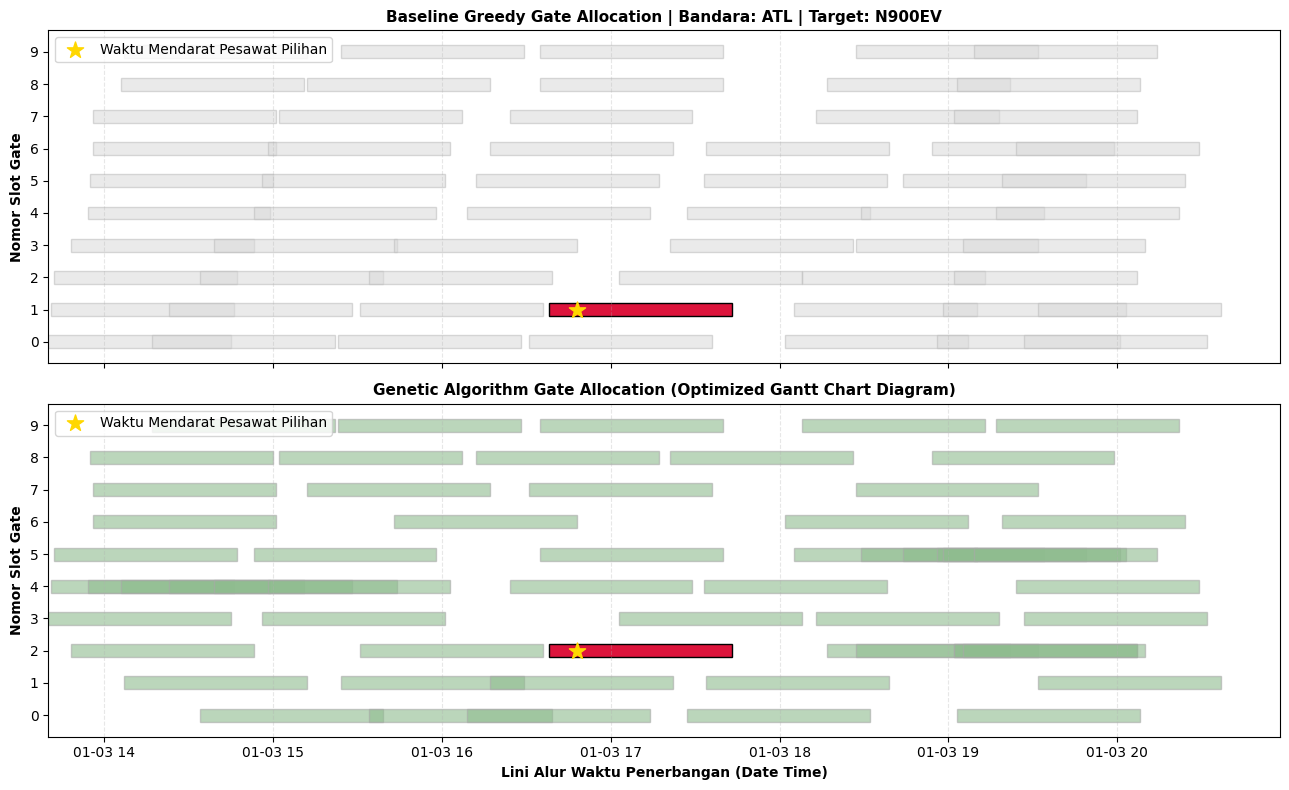

In [ ]:
def jalankan_dashboard_pencarian_operasional(
    df_source: pd.DataFrame, num_gates: int = 10, turnaround_minutes: int = 45,
    buffer_in: int = 10, buffer_out: int = 10, ga_pop: int = 80, ga_gen: int = 80
):
    # Prepare data awal (datetime, keys, dll)
    df = prepare_df_for_gate_opt(df_source)

    print("\n" + "="*90)
    print(" SISTEM EKSPLORASI DAN MITIGASI ADAPTIF LALU LINTAS MAKRO BANDARA")
    print("="*90)

    # LANGKAH 1: MENAMPILKAN SELURUH LIST BANDARA YANG TERSEDIA
    semua_bandara = sorted(df[cols.ArrAirport].dropna().unique().tolist())
    print(f"ℹ️ Total {len(semua_bandara)} Bandara Tujuan Terdeteksi di Dataset.")
    print("ℹ️ Contoh Bandara Utama:", df[cols.ArrAirport].value_counts().head(10).index.tolist())
    print("-" * 90)

    pilihan_bandara = input("TAHAP 1. Masukkan Kode Bandara Tujuan (Contoh: LAX, ORD, ATL): ").strip().upper()
    if pilihan_bandara not in semua_bandara:
        print(f"[Sistem] Kode '{pilihan_bandara}' tidak terdaftar. Mengunci otomatis ke bandara tersibuk: ATL")
        pilihan_bandara = "ATL"

    # Saring data khusus bandara pilihan
    df_airport = df[df[cols.ArrAirport] == pilihan_bandara].copy()

    # LANGKAH 2 & 3: PILIH JAM DAN MASUKKAN JENDELA RADIUS PENCARIAN
    print("\n" + "-"*90)
    print(f"FILTER KRONOLOGIS JENDELA WAKTU OPERASIONAL DI BANDARA {pilihan_bandara}")
    print("-"*90)
    input_jam = input("TAHAP 2. Masukkan Jam Rencana yang Ingin Dipesan (Format HH:MM, Contoh: 14:00): ").strip()

    try:
        h, m = map(int, input_jam.split(":"))
        target_menit_linear = h * 60 + m
    except:
        print("[Sistem] Format jam salah. Otomatis diset ke jam sibuk default: 14:00")
        target_menit_linear = 14 * 60 + 0
        input_jam = "14:00"

    input_radius = input("👉 TAHAP 3. Masukkan Radius Menit Toleransi Pencarian (Contoh: 30 atau 60 menit): ").strip()
    try:
        radius_mnt = int(input_radius)
    except:
        radius_mnt = 45
        print(f"[Sistem] Menggunakan radius default: {radius_mnt} menit")

    # LANGKAH 4: MENYARING & MENAMPILKAN LIST SEMUA PESAWAT YANG AVAILABLE
    def get_row_minutes(dt_series):
        return dt_series.dt.hour * 60 + dt_series.dt.minute

    df_airport["SCHED_MINUTES"] = get_row_minutes(df_airport["SCHED_ARR_DT"])

    min_bound = target_menit_linear - radius_mnt
    max_bound = target_menit_linear + radius_mnt

    df_available_flights = df_airport[
        (df_airport["SCHED_MINUTES"] >= min_bound) &
        (df_airport["SCHED_MINUTES"] <= max_bound)
    ].sort_values("SCHED_ARR_DT").copy()

    if len(df_available_flights) == 0:
        print(f"\n[Sistem] Tidak ada penerbangan terjadwal di {pilihan_bandara} pada rentang waktu {input_jam} (± {radius_mnt} mnt).")
        print("Silakan jalankan ulang Cell ini dan coba masukkan jam operasional lainnya.")
        return

    print("\n" + "-"*90)
    print(f"LIST PESAWAT AVAILABLE DI {pilihan_bandara} PADA RENTANG {input_jam} (± {radius_mnt} MENIT):")
    print(f"   Ditemukan {len(df_available_flights)} jadwal penerbangan aktif.")
    print("-"*90)

    shown_available = df_available_flights.head(25)
    for i, (_, r) in enumerate(shown_available.iterrows(), start=1):
        jam_asli = r['SCHED_ARR_DT'].strftime('%H:%M')
        print(f"   [{i:02d}] Tail: {r[cols.Tail]:7s} | Rute: {r[cols.DepAirport]} -> {r[cols.ArrAirport]} | Jam Rencana Mendarat: {jam_asli} WIB | Estimasi Delay: {int(r['PRED_ARR_DELAY_INT']):+d} mnt")
    print("-"*90)

    pilihan_nomor = input(f"TAHAP 4. Pilih Nomor Urut Pesawat yang Ingin Dimigrasikan Gatenya (1-{len(shown_available)}): ").strip()
    try:
        k = int(pilihan_nomor)
        if not (1 <= k <= len(shown_available)): raise ValueError
    except ValueError:
        k = 1
        print("[Sistem] Input tidak valid, otomatis memproses pesawat urutan nomor 1.")

    row_user = shown_available.iloc[k-1]
    pilihan_pesawat = row_user[cols.Tail]
    user_key = row_user["FLIGHT_KEY"]

    center = row_user["PRED_ARR_DT"]
    start_w = center - pd.Timedelta(minutes=180)
    end_w = center + pd.Timedelta(minutes=180)

    df_window = df_airport[(df_airport["PRED_ARR_DT"] >= start_w) & (df_airport["PRED_ARR_DT"] <= end_w)].copy()
    if user_key not in df_window["FLIGHT_KEY"].values:
        df_window = pd.concat([df_window, df_airport[df_airport["FLIGHT_KEY"] == user_key]], ignore_index=True)
    df_window = df_window.drop_duplicates(subset=["FLIGHT_KEY"]).sort_values("PRED_ARR_DT").reset_index(drop=True)

    t0 = df_window["PRED_ARR_DT"].min()
    flights_for_opt = []
    for _, r in df_window.iterrows():
        arr_dt = r["PRED_ARR_DT"]
        start_dt = arr_dt - pd.Timedelta(minutes=buffer_in)
        end_dt = arr_dt + pd.Timedelta(minutes=(turnaround_minutes + buffer_out))
        flights_for_opt.append({
            "flight_key": r["FLIGHT_KEY"], "tail": r[cols.Tail], "sched_arr_dt": r["SCHED_ARR_DT"],
            "pred_arr_dt": r["PRED_ARR_DT"], "act_arr_dt": r["ACT_ARR_DT"], "pred_arr_delay": int(r["PRED_ARR_DELAY_INT"]),
            "act_arr_delay": int(r["ARR_DELAY_INT"]), "dep_delay": int(r["DEP_DELAY_INT"]),
            "start_dt": start_dt, "end_dt": end_dt,
            "start_min": int((start_dt - t0).total_seconds() // 60),
            "end_min": int((end_dt - t0).total_seconds() // 60)
        })

    user_i = next((i for i, f in enumerate(flights_for_opt) if f["flight_key"] == user_key), 0)

    # komparasi Greedy vs GA
    greedy_assign = greedy_gate_assignment(flights_for_opt, num_gates=num_gates)
    greedy_metrics = doublebooked_union_metrics(flights_for_opt, greedy_assign, num_gates=num_gates)

    ga = AirportGateGA(flights_data=flights_for_opt, num_gates=num_gates, pop_size=ga_pop, generations=ga_gen)
    ga_assign = ga.run_optimization()
    ga_metrics = doublebooked_union_metrics(flights_for_opt, ga_assign, num_gates=num_gates)

    # INTERFACES LAPORAN & PLOT GANTT CHART
    print("\n" + "✓"*90)
    print("EMBERITAHUAN OPERASIONAL ADAPTIF BANDARA (FLIGHT LOGISTICS INSPECTION)")
    print("✓"*90)
    print(f"Nomor Lambung Pesawat   : {row_user[cols.Tail]}")
    print(f"Rute Penerbangan        : {row_user[cols.DepAirport]} -> {pilihan_bandara}")
    print(f"Jam Rencana Mendarat     : {row_user['SCHED_ARR_DT'].strftime('%H:%M')} WIB")
    print("-" * 90)
    print("METRIKS DISTRIBUSI KETERLAMBATAN (MENIT):")
    print(f"   • Delay Keberangkatan (Asal) : {int(row_user['DEP_DELAY_INT']):+d} Menit")
    print(f"   • Prediksi Delay Tiba (AI)   : {int(row_user['PRED_ARR_DELAY_INT']):+d} Menit")
    print(f"   • Aktual Delay Tiba (Nyata)  : {int(row_user['ARR_DELAY_INT']):+d} Menit")
    print("-" * 90)
    print("KOMPARASI KRONOLOGIS JENDELA WAKTU TIBA (JAM):")
    print(f"   • Perkiraan Tiba Hasil AI    : Pukul {row_user['PRED_ARR_DT'].strftime('%H:%M')} WIB")
    print(f"   • Aktual Mendarat di Lapangan: Pukul {row_user['ACT_ARR_DT'].strftime('%H:%M')} WIB")
    print("-" * 90)
    print("EVALUASI PERFORMA MITIGASI ALOKASI GATE (KOMPARATIF):")
    print(f"   • GREEDY GATE (Baseline)  : [ GATE {int(greedy_assign[user_i])} ]")
    print(f"     - Konflik Double-booked : {greedy_metrics['doublebooked_union_min']:.0f} Menit | Total Unit Konflik: {greedy_metrics['conflict_flights']:.0f} Pesawat")
    print(f"   • GA GATE (Optimized)     : [ GATE {int(ga_assign[user_i])} ]")
    print(f"     - Konflik Double-booked : {ga_metrics['doublebooked_union_min']:.0f} Menit | Total Unit Konflik: {ga_metrics['conflict_flights']:.0f} Pesawat")
    print("="*90)

    # Plotting Gantt Chart
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    # Top Plot: Greedy
    axes[0].set_title(f"Baseline Greedy Gate Allocation | Bandara: {pilihan_bandara} | Target: {pilihan_pesawat}", fontweight="bold", fontsize=11)
    for i, f in enumerate(flights_for_opt):
        g = greedy_assign[i]
        is_user = (i == user_i)
        axes[0].barh(g, left=f["start_dt"], width=f["end_dt"] - f["start_dt"], color="crimson" if is_user else "gainsboro", edgecolor="black" if is_user else "silver", alpha=1.0 if is_user else 0.6, height=0.4)
        if is_user: axes[0].scatter(f["pred_arr_dt"], g, color="gold", marker="*", s=150, zorder=5, label="Waktu Mendarat Pesawat Pilihan")
    axes[0].set_ylabel("Nomor Slot Gate", fontweight="bold")
    axes[0].set_yticks(range(num_gates))
    axes[0].grid(True, linestyle="--", alpha=0.3, axis="x")
    axes[0].legend(loc="upper left")

    # Bottom Plot: GA
    axes[1].set_title("Genetic Algorithm Gate Allocation (Optimized Gantt Chart Diagram)", fontweight="bold", fontsize=11)
    for i, f in enumerate(flights_for_opt):
        g = ga_assign[i]
        is_user = (i == user_i)
        axes[1].barh(g, left=f["start_dt"], width=f["end_dt"] - f["start_dt"], color="crimson" if is_user else "darkseagreen", edgecolor="black" if is_user else "darkgray", alpha=1.0 if is_user else 0.6, height=0.4)
        if is_user: axes[1].scatter(f["pred_arr_dt"], g, color="gold", marker="*", s=150, zorder=5, label="Waktu Mendarat Pesawat Pilihan")
    axes[1].set_xlabel("Lini Alur Waktu Penerbangan (Date Time)", fontweight="bold", fontsize=10)
    axes[1].set_ylabel("Nomor Slot Gate", fontweight="bold")
    axes[1].set_yticks(range(num_gates))
    axes[1].grid(True, linestyle="--", alpha=0.3, axis="x")
    axes[1].legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# Eksekusi Panel Dashboard Menggunakan Alur Baru
if 'df_global_result' in locals():
    jalankan_dashboard_pencarian_operasional(df_global_result)